# polynomial regression

* non linearity 
* interaction

# step1: bussiness problem understanding

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

# step2: data collection

* 2.1: load data & understanding every variable

In [2]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\nages\Downloads\advertising.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


# data understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.shape

(200, 4)

In [5]:
df.size

800

# step 3: data preprocessing

# eda(exploratary data analysis)

In [6]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


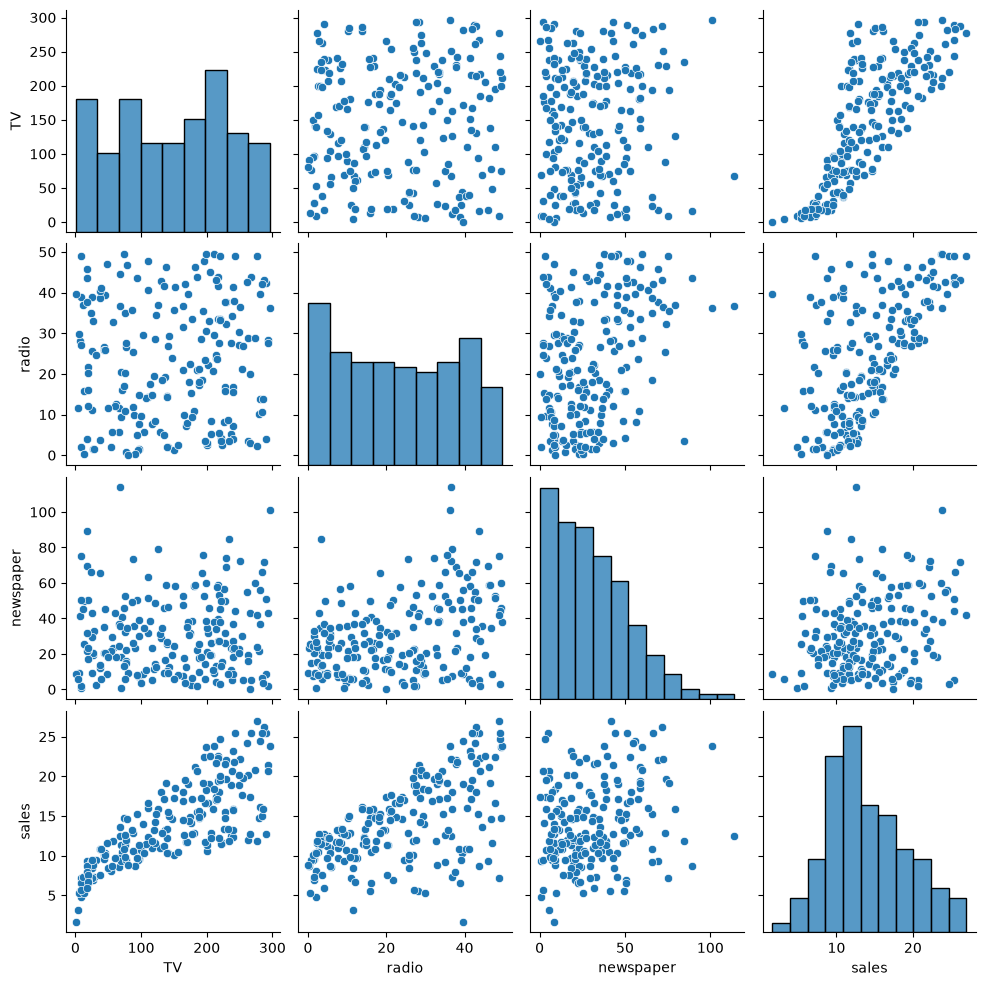

In [7]:
sns.pairplot(df)
plt.show()

In [8]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


# step4: data cleaning

In [9]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

# step5: data wrangling

In [10]:
# no encoding is required

# x&y

In [11]:
x=df.drop(columns="sales")
y=df["sales"]

In [12]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
x_poly=polynomial_converter.fit_transform(x)
x_poly=pd.DataFrame(x_poly)

# train test split

from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(x_poly,y,test_size=0.2,random_state=42)

# modeling

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

# predicting

trainpredictions=model.predict(x_train)

testpredictions=model.predict(x_test)




# train test split

In [13]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(x_poly,y,test_size=0.3,random_state=42)

* transform our original data set by adding polynomial features

In [14]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
x_train=pd.DataFrame(polynomial_converter.fit_transform(x_train))
x_test=pd.DataFrame(polynomial_converter.fit_transform(x_test))



In [15]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](54,)","[ 0.,-0., 0.,..., 0.,-0., 0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.971
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,54
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,22
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](54,)","[1.42e+10,1.49e+09,9.14e+08,...,1.33e-06,1.33e-06,1.33e-06]"


In [16]:
model.intercept_

np.float64(7.971317515212676)

In [17]:
model.coef_

array([ 2.53122942e-07, -1.74654523e-08,  7.27807533e-09,  1.36737979e-05,
        3.57279520e-06,  3.05121815e-06, -3.14499224e-07, -9.60977039e-07,
        2.64522079e-07,  1.36737979e-05,  3.57279520e-06,  3.05121815e-06,
        1.52420363e-06, -6.18428878e-07, -4.77814737e-06,  8.68563354e-05,
       -3.16246321e-05,  3.05906365e-05, -3.14499224e-07, -9.60977039e-07,
       -6.18428878e-07,  8.68563354e-05, -3.16246321e-05, -5.39699330e-06,
       -1.72029386e-05, -2.79768436e-05,  2.64522079e-07, -4.77814737e-06,
       -3.16246321e-05,  3.05906365e-05, -1.72029386e-05, -2.79768436e-05,
        4.36731157e-06, -5.72027109e-09,  2.16421910e-08,  3.22247186e-08,
       -3.56343114e-07,  2.82549073e-07, -1.17332539e-07, -3.56343114e-07,
        2.82549073e-07,  3.65403269e-07, -4.22011954e-07, -1.36958701e-08,
       -1.17332539e-07, -4.22011954e-07, -1.36958701e-08, -3.55998356e-08,
       -2.20905844e-06,  3.40557849e-07,  1.72214324e-06,  1.72214324e-06,
       -9.67982377e-07,  

# predictions

In [18]:
trainpredictions=model.predict(x_train)

In [19]:
testpredictions=model.predict(x_test)

# evalution

In [20]:
from sklearn.metrics import mean_absolute_error
print("MAE for test data:",mean_absolute_error(y_test,testpredictions))
print("MAE for train data:",mean_absolute_error(y_train,trainpredictions))

MAE for test data: 1.3799440650317065
MAE for train data: 0.5388409090912881


In [21]:
from sklearn.metrics import mean_squared_error
print("MSE for test data:",mean_squared_error(y_test,testpredictions))
print("MSE for train data:",mean_squared_error(y_train,trainpredictions))

MSE for test data: 5.591704897810235
MSE for train data: 0.4839215639533008


In [22]:
from sklearn.metrics import r2_score
print("R2 for test data:",r2_score(y_test,testpredictions))
print("R2 for train data:",r2_score(y_train,trainpredictions))

R2 for test data: 0.7869095447077414
R2 for train data: 0.982276927101623


In [23]:
model.score(x_test,y_test)

0.7869095447077414

In [24]:
model.score(x_train,y_train)

0.982276927101623

# cross validation

In [25]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,x_poly,y,cv=5)
print(scores)
cv_score = scores.mean()
print("cross Validation Score:",cv_score)

[0.98795615 0.98937857 0.99129812 0.95889074 0.99374691]
cross Validation Score: 0.9842540981580088


# hyper parameter tuning

In [26]:
train_r2=[]
test_r2=[]
for i in range(1,10):
    from sklearn.preprocessing import PolynomialFeatures
    polynomial_converter=PolynomialFeatures(degree=i,include_bias=False)
    x_poly=polynomial_converter.fit_transform(x)
    x_poly=pd.DataFrame(x_poly)

# train test split

    from sklearn.model_selection import train_test_split
    x_test,x_train,y_test,y_train=train_test_split(x_poly,y,test_size=0.3,random_state=42)

# modeling

    from sklearn.linear_model import LinearRegression
    model=LinearRegression()
    model.fit(x_train,y_train)

# predicting

    trainpredictions=model.predict(x_train)

    testpredictions=model.predict(x_test)

# check r2 score
    train_r2.append(model.score(x_train,y_train))
    test_r2.append(model.score(x_test,y_test))


In [27]:
train_r2

[0.8933785146758415,
 0.98971926499102,
 0.9876917675182244,
 0.9827723038669579,
 0.9646659653063688,
 0.9449615011851152,
 0.9278187802995101,
 0.9043833868000923,
 0.8827311340334977]

In [28]:
test_r2

[0.8767740349226146,
 0.9820345733718835,
 0.9685412722735439,
 0.7974717550911018,
 -0.05482175859286098,
 -2.5130335434673605,
 -3.568934774274328,
 -7.693738033230842,
 -34.04891902656273]

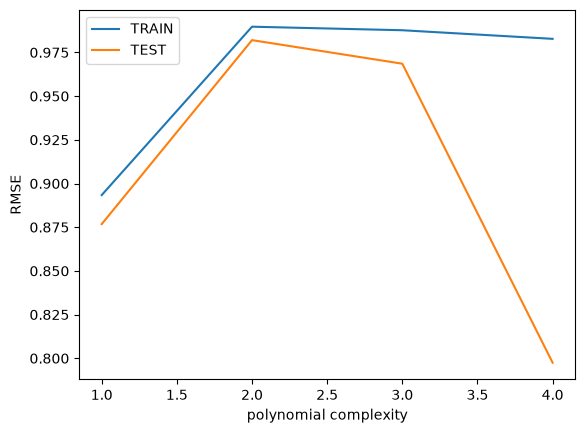

In [29]:
plt.plot(range(1,5),train_r2[:4],label="TRAIN")
plt.plot(range(1,5),test_r2[:4],label="TEST")
plt.xlabel("polynomial complexity")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [51]:
# preprocessing
final_poly_converter=PolynomialFeatures(degree=3,include_bias=False)
x_poly=final_poly_converter.fit_transform(x)

#train test split
 

x_test,x_train,y_test,y_train=train_test_split(x_poly,y,test_size=0.2,random_state=42)

# build the final model

final_model=LinearRegression()
final_model.fit(x_train,y_train)

# prediction

trainpredictions=final_model.predict(x_train)
testpredictions=final_model.predict(x_test)

# evalution

print("TREAIN R2:",final_model.score(x_train,y_train))
print("TEST R2:",final_model.score(x_test,y_test))

TREAIN R2: 0.9906694714748662
TEST R2: 0.9634781529758876


In [52]:
input_data=[[19000,22000,12000]]
final_model.predict(input_data)

ValueError: X has 3 features, but LinearRegression is expecting 19 features as input.

In [53]:
input_data=[[14900,22000,12000]]
transformed_data=final_poly_converter.fit_transform(input_data)
final_model.predict(transformed_data)

array([9.58359315e+08])

# save the model

In [54]:
from joblib import dump

In [55]:
dump(final_poly_converter,"polynomial_converter.joblib")

['polynomial_converter.joblib']

In [56]:
dump(final_model,"sales_poly_model.joblib")

['sales_poly_model.joblib']

# load the model

In [57]:
from joblib import load

In [58]:
loaded_poly=load("polynomial_converter.joblib")
loaded_model=load("sales_poly_model.joblib")

In [59]:
campaign_poly=loaded_poly.transform([[149000,22000,12000]])
loaded_model.predict(campaign_poly)

array([-2.4934363e+09])